## Figure: RegMean Loss

/tmp/ipykernel_1023923/922375783.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfp = dfp[df["model"] == "Olmo-3-7b"]


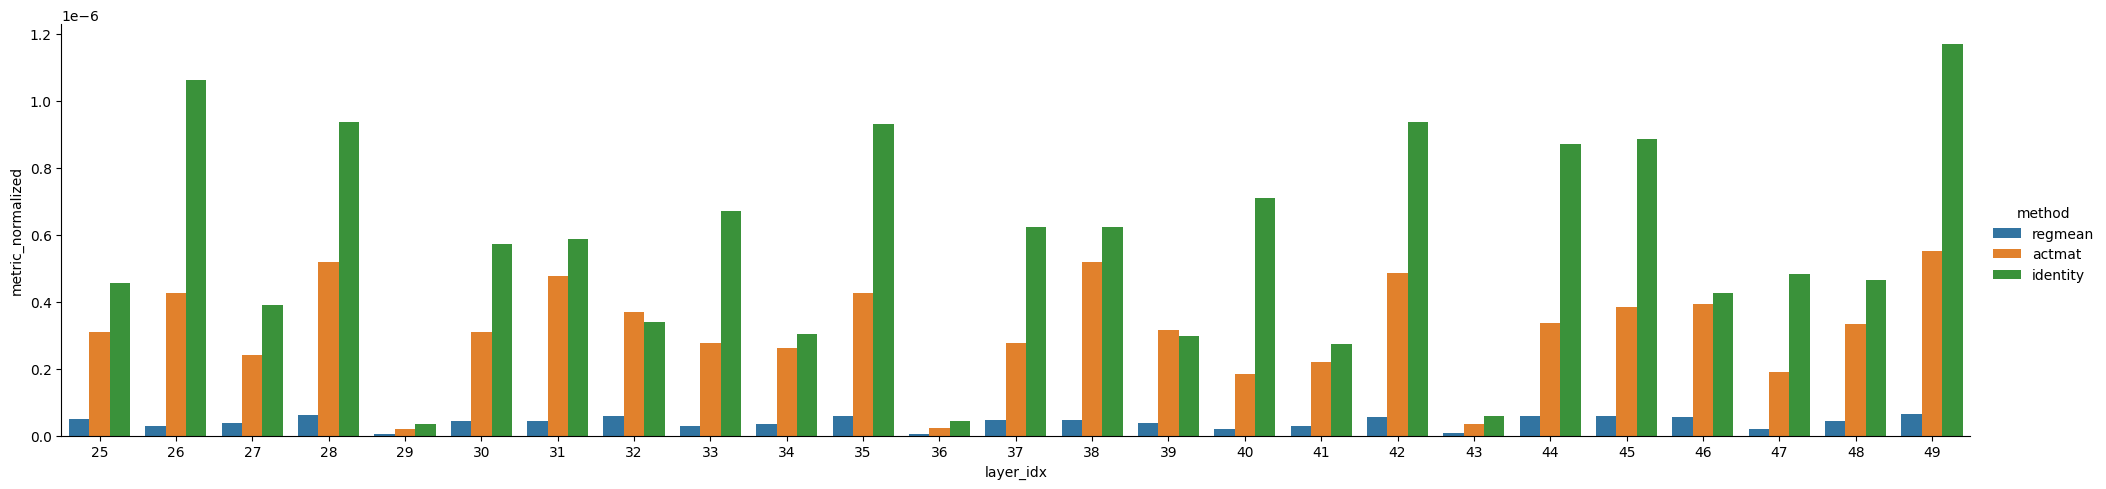

In [38]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == "rm_loss"]
dfp = dfp[df["model"] == "Olmo-3-7b"]
# dfp = dfp[df["model"] == "t5-large"]
# dfp = dfp[df["model"] == "ViT-L-14"]
dfp["metric_normalized"] = dfp["metric"] / (dfp["Do"] * dfp["Di"])
dfp = dfp[dfp["method"].isin(["actmat", "regmean", "identity"])]
dfp = dfp[(dfp["layer_idx"] >= 25) & (dfp["layer_idx"] < 50)]

g = sns.catplot(
    dfp,
    x="layer_idx",
    y="metric_normalized",
    hue="method",
    hue_order=["regmean", "actmat", "identity"],
    # style="method",
    kind="bar",
    # markers=True,
    aspect=4,
)
# g.set(yscale="log")
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

/tmp/ipykernel_1023923/4210680141.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfp = dfp[df["model"] == model]


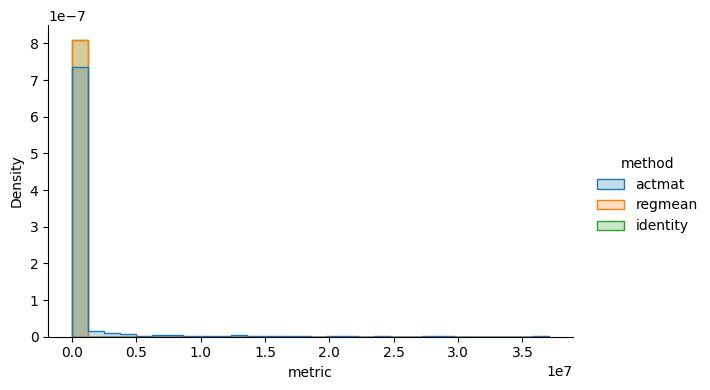

In [12]:
import pandas as pd
import seaborn as sns

metric_type = "cosine_similarity"
# metric_type = "rm_loss"
# model = "Olmo-3-7b"
model = "ViT-B-16"
df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == metric_type]
dfp = df[df["method"].isin(["regmean", "identity", "actmat"])]
dfp = dfp[df["model"] == model]

g = sns.displot(
    dfp,
    x="metric",
    hue="method",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    bins=30,
    height=4,
    aspect=1.5,
)

In [2]:
dfp

,model,method,layer,layer_idx,metric_type,metric,Di,Do
27712,Olmo-3-7b,actmat,lm_head.weight,0,rm_loss,5450.107422,4096,100278
27720,Olmo-3-7b,actmat-identity-inv,lm_head.weight,0,rm_loss,8017.191406,4096,100278
27728,Olmo-3-7b,regmean,lm_head.weight,0,rm_loss,690.046875,4096,100278
27736,Olmo-3-7b,identity,lm_head.weight,0,rm_loss,5185.236816,4096,100278
27744,Olmo-3-7b,actmat,model.layers.0.mlp.down_proj.weight,1,rm_loss,0.099288,11008,4096
...,...,...,...,...,...,...,...,...
34872,Olmo-3-7b,identity,model.layers.9.self_attn.q_proj.weight,223,rm_loss,2.370270,4096,4096
34880,Olmo-3-7b,actmat,model.layers.9.self_attn.v_proj.weight,224,rm_loss,5.834961,4096,4096
34888,Olmo-3-7b,actmat-identity-inv,model.layers.9.self_attn.v_proj.weight,224,rm_loss,19.214134,4096,4096
34896,Olmo-3-7b,regmean,model.layers.9.self_attn.v_proj.weight,224,rm_loss,0.742409,4096,4096


In [ ]:
# import pandas as pd
# import seaborn as sns

# df = pd.read_csv("../artifacts/analysis/cov-estimate-error/cov-estimate-error.csv")
# dfp = df.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat"])
# dfp.style.format("{:.2e}")

# import pandas as pd
# import seaborn as sns

# df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
# dfp = df[df["metric_type"] == "rm_loss"]
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

## Error terms

### Figure: layer-wise error terms

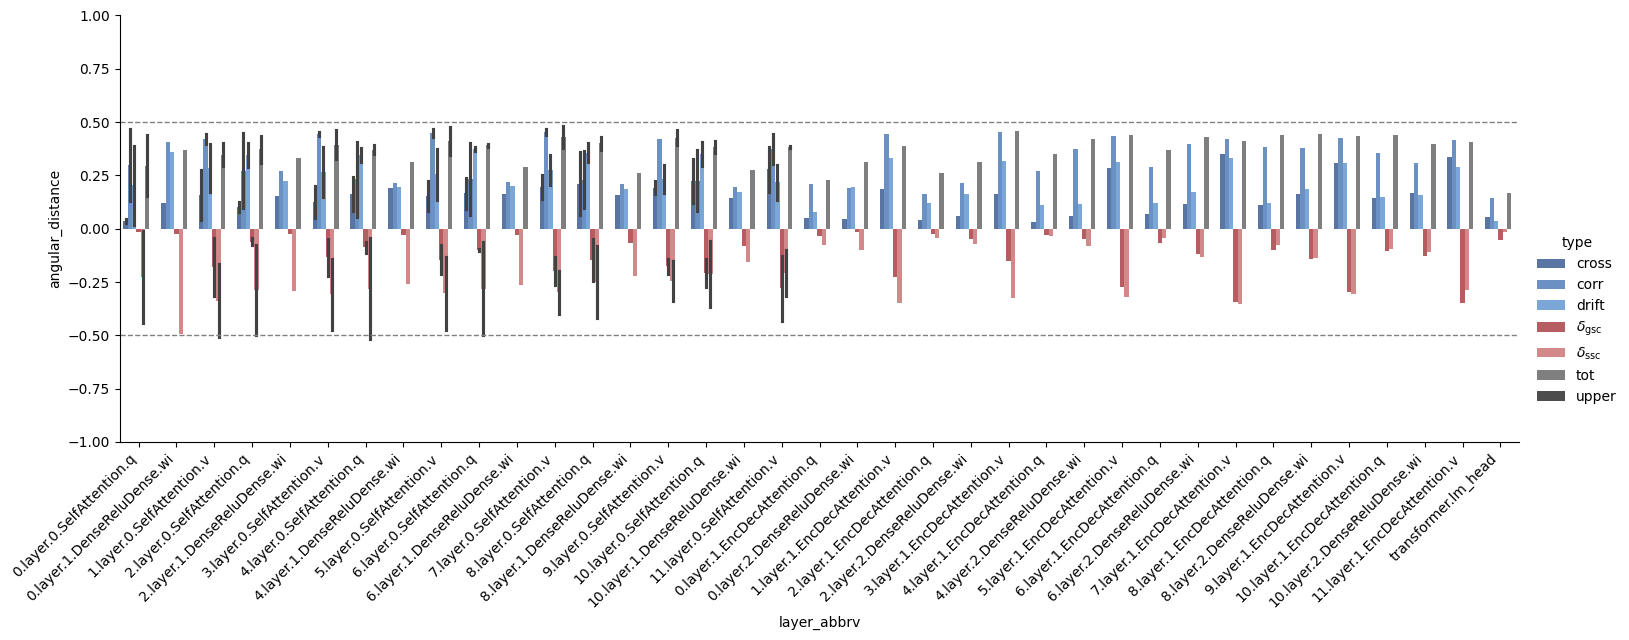

In [ ]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

results_dir = f"../artifacts/results/ViT-B-16/group-fft-8"
results_dir = f"../artifacts/results/t5-base/group-fft-7"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

# Filters:
# df = df[df["dataset"] == "Cars"]
# df = df[df["dataset"] == "DTD"]
# df = df[df["dataset"] == "MNIST"]
# df = df[df["dataset"] == "SVHN"]
df = df[df["dataset"] == "paws"]
df = df[df["layer_idx"] % 416 == 0]

# Make layer abbrv
replace_strs = {
    "model.visual.transformer.resblocks.": "",
    ".weight": "",
    "transformer.encoder.block.": "",
    "transformer.decoder.block.": "",
}

df["layer_abbrv"] = df["layer_name"]
for old, new in replace_strs.items():
    df["layer_abbrv"] = df["layer_abbrv"].str.replace(old, new, regex=False)

hue_order = [
    "cross",
    "corr",
    "drift",
    r"$\delta_\text{gsc}$",
    r"$\delta_\text{ssc}$",
    "tot",
    "upper",
]

palette = {
    "cross": "#4C72B0",  # blues for the ε error terms
    "corr": "#5B8FCF",
    "drift": "#6BA6E8",
    r"$\delta_\text{gsc}$": "#C44E52",  # reds for the δ slack terms
    r"$\delta_\text{ssc}$": "#E07B7E",
    "tot": "#7F7F7F",  # grey for the total
    "upper": "#4D4D4D",  # darker grey for the triangle-inequality bound
}

g = sns.catplot(
    data=df,
    x="layer_abbrv",
    y="angular_distance",
    kind="bar",
    hue="type",
    aspect=3,
    hue_order=hue_order,
    palette=palette,
)
g.set_xticklabels(rotation=45, ha="right")
g.set(ylim=(-1.0, 1.0))
g.ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
g.ax.axhline(-0.5, color="grey", linestyle="--", linewidth=1)

In [ ]:
df

,dataset,layer_name,layer_idx,angular_distance,type,layer_abbrv
0,Cars,model.visual.transformer.resblocks.0.attn.q,0,0.400619,cross,0.attn.q
1,Cars,model.visual.transformer.resblocks.0.attn.q,0,0.225616,corr,0.attn.q
2,Cars,model.visual.transformer.resblocks.0.attn.q,0,0.209662,drift,0.attn.q
3,Cars,model.visual.transformer.resblocks.0.attn.q,0,0.421072,tot,0.attn.q
4,Cars,model.visual.transformer.resblocks.0.attn.q,0,0.835896,upper,0.attn.q
...,...,...,...,...,...,...
2998,RESISC45,model.visual.transformer.resblocks.11.attn.v,68,0.090026,drift,11.attn.v
2999,RESISC45,model.visual.transformer.resblocks.11.attn.v,68,0.282157,tot,11.attn.v
3000,RESISC45,model.visual.transformer.resblocks.11.attn.v,68,0.892383,upper,11.attn.v
3001,RESISC45,model.visual.transformer.resblocks.11.attn.v,68,-0.518524,$\delta_\text{gsc}$,11.attn.v


### Figure: dataset-wise error terms

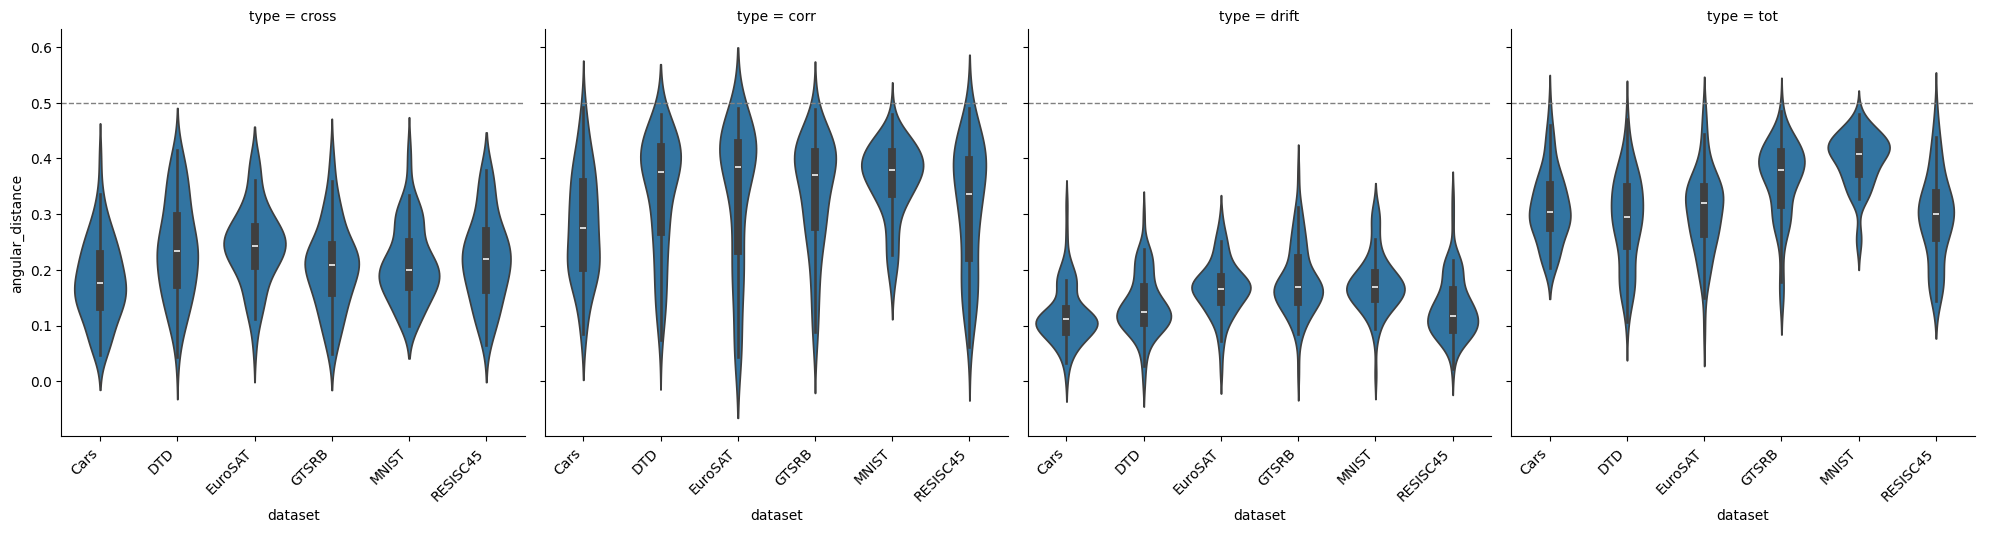

In [1]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/ViT-B-16/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))
df = df[df["type"].isin(["cross", "corr", "drift", "tot"])]

g = sns.catplot(data=df, x="dataset", y="angular_distance", kind="violin", col="type")
g.set_xticklabels(rotation=45, ha="right")
for ax in g.axes.flat:
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)

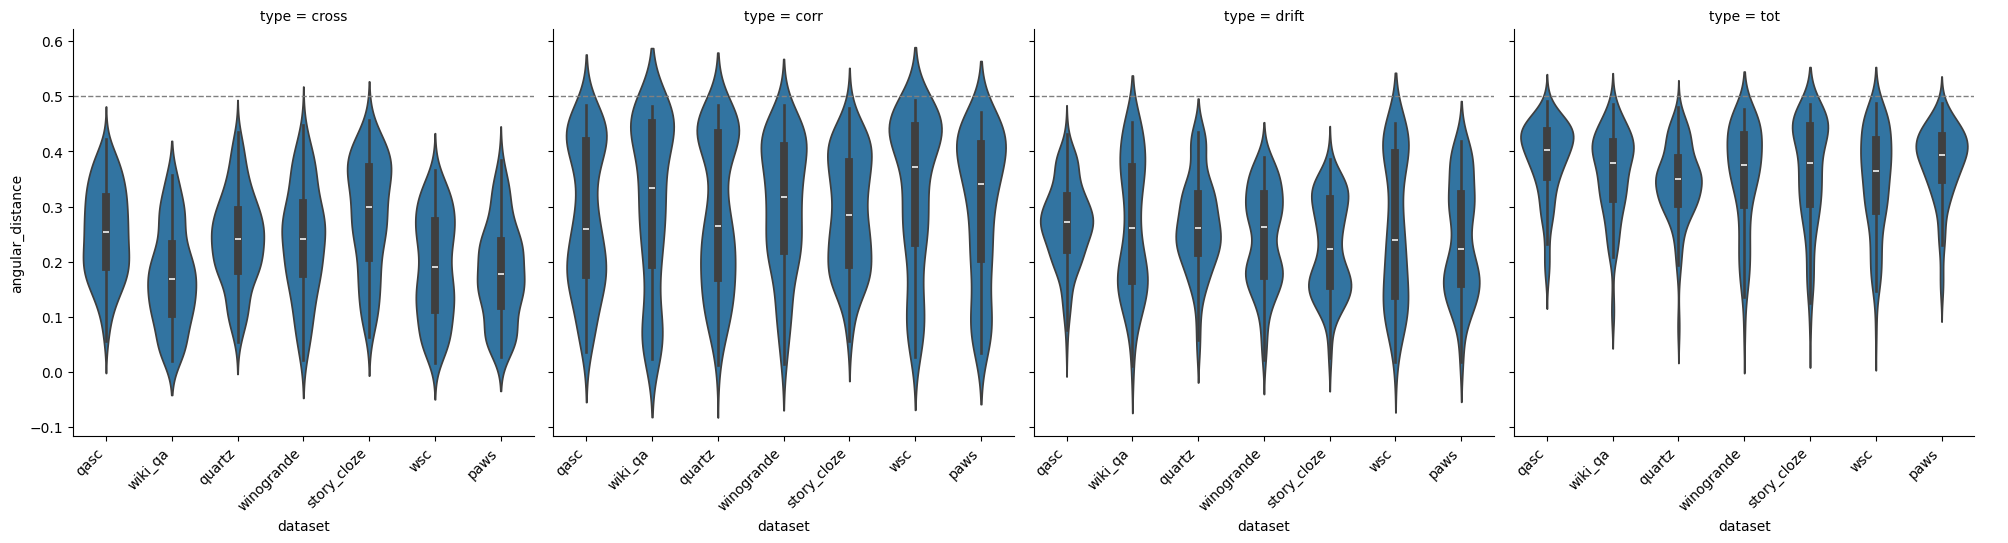

In [ ]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

results_dir = f"../artifacts/results/t5-base/group-fft-7"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))
df = df[df["type"].isin(["cross", "corr", "drift", "tot"])]

g = sns.catplot(data=df, x="dataset", y="angular_distance", kind="violin", col="type")
g.set_xticklabels(rotation=45, ha="right")
for ax in g.axes.flat:
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)

### Table: Error Terms

In [23]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

dfp = df.pivot_table(index="type", columns="dataset", values="angular_distance")
dfp

dataset,Cars,DTD,EuroSAT,GTSRB,MNIST,RESISC45
type,,,,,,
$\delta_\text{gsc}$,-0.179592,-0.307068,-0.303579,-0.227361,-0.219166,-0.263689
$\delta_\text{ssc}$,-0.086386,-0.114179,-0.134116,-0.135077,-0.129760,-0.106676
corr,0.278984,0.337374,0.333555,0.336815,0.360813,0.312180
cross,0.180975,0.237507,0.242447,0.206055,0.211024,0.220130
drift,0.119398,0.136773,0.167534,0.180341,0.174745,0.133614
tot,0.313380,0.290408,0.305841,0.360772,0.397655,0.295558
upper,0.579358,0.711655,0.743537,0.723210,0.746582,0.665924


## Figure: Layer-wise Cosine similarity histogram

In [40]:
import argparse
import math
import os
import os.path as osp
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

sys.path.append("..")

from src.vit.experts import ViTExpert, optional_sidecar  # noqa: E402

abs_cos = lambda a, b: ((a * b).sum() / (a.norm() * b.norm())).abs().item()

DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

# method -> effective covariance estimate; same cov_est_fn(d, c) contract as the
# table. regmean is the trivial reference (|cos| == 1 everywhere).
configs = {
    "regmean": lambda d, c: c,
    "actmat": lambda d, c: d.T @ d,
    "identity": lambda d, c: torch.eye(c.shape[-1]),
}

experts_dir = osp.join(
    "../artifacts/checkpoints", "ViT-B-16", f"group-fft-8", "experts"
)
base = ViTExpert(weights_path=osp.join(experts_dir, DATASETS[0], "pretrained.pt"))
experts = [
    ViTExpert(
        weights_path=osp.join(experts_dir, ds, "finetuned.pt"),
        covariance_path=optional_sidecar(osp.join(experts_dir, ds), "covariance.pt"),
    )
    for ds in DATASETS
]

rows = []  # one |cos| per (task, layer, method)
for ds, exp in zip(DATASETS, experts):
    for layer in exp.get_layers():
        c, d = exp.get_layer_cov(layer), exp.get_layer_params(layer)
        if c is None or d.ndim != 2 or c.shape[-1] != d.shape[-1]:
            continue
        c, d = c.float(), (d - base.get_layer_params(layer)).float()
        for method, fn in configs.items():
            rows.append(
                {"method": method, "abs_cos": abs_cos(c, fn(d, c)), "dataset": ds}
            )

In [39]:
df = pd.DataFrame(rows)
g = sns.displot(
    df,
    x="abs_cos",
    hue="method",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    # col="dataset",
    # col_wrap=3,
    bins=30,
    height=4,
    aspect=1.5,
)
g.set_axis_labels(r"$|\cos(c,\ \hat c)|$", "density")

ValueError: Could not interpret value `abs_cos` for `x`. An entry with this name does not appear in `data`.

## Figure: Layer-wise RM Loss Hist

In [26]:
import argparse
import math
import os
import os.path as osp
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

sys.path.append("..")

from src.vit.experts import ViTExpert, optional_sidecar  # noqa: E402

tr_abt = lambda a, b: (a * b).sum()
pinv = lambda c: torch.linalg.pinv(c, hermitian=True)  # c is symmetric PSD

# ***************************************************************************
# Regmean objective
# ***************************************************************************


def compute_rm_loss(w_test, w_t, c_t):
    """Compute the RegMean loss for linear layer at a given w

    Args:
        w_test: (Do, Di)      merged delta (w* - w_0)
        w_t:    (T, Do, Di)   per-expert deltas
        c_t:    (T, Di, Di)   per-expert (real) covariances
    """
    w_test = w_test.unsqueeze(0)
    loss_1 = tr_abt(w_test @ c_t, w_test)
    loss_2 = tr_abt(w_t @ c_t, w_t)
    loss_3 = tr_abt(w_t @ c_t, w_test)
    return loss_1 + loss_2 - 2 * loss_3


# ***************************************************************************
# Merge methods
# ***************************************************************************
def merge_actmat(w0: torch.Tensor, d: torch.Tensor, **kwargs):
    c = d.transpose(-2, -1) @ d
    return w0 + (d @ c).sum(dim=0) @ torch.linalg.pinv(c.sum(dim=0))


def merge_regmean(w0: torch.Tensor, d: torch.Tensor, c: torch.Tensor, **kwargs):
    return w0 + (d @ c).sum(dim=0) @ torch.linalg.pinv(c.sum(dim=0))


def merge_mean(w0: torch.Tensor, d: torch.Tensor, **kwargs):
    return w0 + d.mean(0)


DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

# method -> effective covariance estimate; same cov_est_fn(d, c) contract as the
# table. regmean is the trivial reference (|cos| == 1 everywhere).
configs = {"regmean": merge_regmean, "actmat": merge_actmat, "mean": merge_mean}

experts_dir = osp.join(
    "../artifacts/checkpoints", "ViT-B-16", f"group-fft-8", "experts"
)
base = ViTExpert(weights_path=osp.join(experts_dir, DATASETS[0], "pretrained.pt"))
experts = [
    ViTExpert(
        weights_path=osp.join(experts_dir, ds, "finetuned.pt"),
        covariance_path=optional_sidecar(osp.join(experts_dir, ds), "covariance.pt"),
    )
    for ds in DATASETS
]

rows = []
for layer in tqdm(experts[0].get_layers()):
    c = [exp.get_layer_cov(layer) for exp in experts]
    w = [exp.get_layer_params(layer) for exp in experts]
    w0 = base.get_layer_params(layer)
    if c[0] is None or w[0].ndim != 2:
        continue
    d = torch.stack([wt - w0 for wt in w])
    c = torch.stack(c)
    for method, fn in configs.items():
        rows.append(
            {
                "method": method,
                "layer": layer,
                "rm_loss": compute_rm_loss(fn(w0, d, c=c) - w0, d, c).item(),
                "Di": w0.shape[-1],
                "Do": w0.shape[-2],
            }
        )

100%|██████████| 206/206 [15:51<00:00,  4.62s/it]


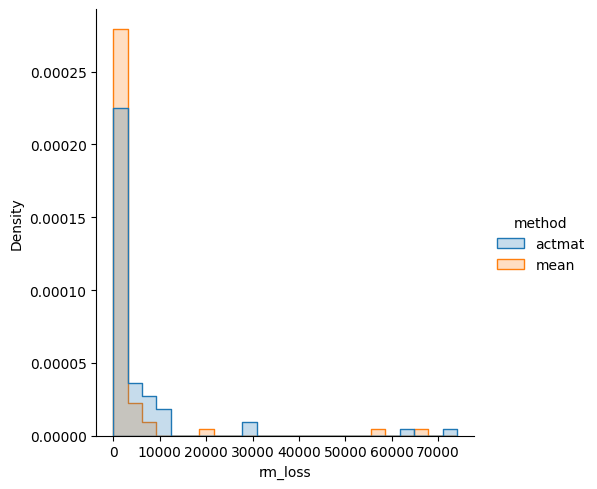

In [25]:
df = pd.DataFrame(rows)
df["rm_loss"] = df["rm_loss"].apply(lambda x: x.item())
df = df[df["method"].isin(["actmat", "mean"])]
g = sns.displot(
    df,
    x="rm_loss",
    hue="method",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    # col="dataset",
    # col_wrap=3,
    # bins=30,
    # height=4,
    # aspect=1.5,
)

## Table: Merge Performance (ViT)

In [2]:
import os
import os.path as osp
import glob
import json
import numpy as np
import pandas as pd
import seaborn as sns


class ViTMetrics:
    def __init__(self, path):
        self.path = path

    @property
    def avg_score(self):
        if not os.path.exists(self.path):
            # print(f"[skipped] file dne {self.path}")
            return None
        with open(self.path, "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            return avg_score

    @property
    def task_wise_scores(self):
        if not os.path.exists(self.path):
            # print(f"[skipped] file dne {self.path}")
            return None
        with open(self.path, "r") as f:
            metrics = json.load(f)
            return {t["alias"]: t["metrics"]["primary_score"] for t in metrics["tasks"]}


class OlmoMetrics:
    task_to_metric = {
        "codex_humaneval::tulu": "pass_at_1",
        "codex_humanevalplus::tulu": "pass_at_1",
        "ifeval::tulu": "prompt_level_loose_acc",
        "aime:zs_cot_r1::pass_at_32_2024_deepseek": "pass_at_1",
        "aime:zs_cot_r1::pass_at_32_2025_deepseek": "pass_at_1",
        "gsm8k::tulu": "exact_match",
        "minerva_math_500::tulu": "math_verify",
    }

    task_to_chat_templ = {
        "codex_humaneval::tulu": "code",
        "codex_humanevalplus::tulu": "code",
        "ifeval::tulu": "code",
        "aime:zs_cot_r1::pass_at_32_2024_deepseek": "math",
        "aime:zs_cot_r1::pass_at_32_2025_deepseek": "math",
        "gsm8k::tulu": "math",
        "minerva_math_500::tulu": "math",
    }

    def __init__(self, path):
        self.path = path

    def _math_verify_score(self, results_dir):
        prediction_paths = glob.glob(
            osp.join(results_dir, "*minerva*predictions.jsonl")
        )
        if not prediction_paths:
            return None
        vals = [
            json.loads(line)["metrics"].get("math_verify", 0)
            for line in open(prediction_paths[0])
        ]
        if not vals:
            return None
        return np.mean(vals)

    @property
    def avg_score(self):
        metrics_paths = [self.path]
        if not os.path.exists(self.path):
            run_dir = osp.dirname(self.path)
            metrics_paths = [
                osp.join(run_dir, "ct-code", "metrics.json"),
                osp.join(run_dir, "ct-math", "metrics.json"),
            ]

        scores = []
        for path in metrics_paths:
            if not os.path.exists(path):
                # print(f"[skipped] file dne {path}")
                continue
            chat_templ = osp.basename(osp.dirname(path)).replace("ct-", "")
            with open(path, "r") as f:
                metrics = json.load(f)
            for task in metrics["tasks"]:
                alias = task["alias"]
                if self.task_to_chat_templ.get(alias) != chat_templ:
                    continue
                metric = self.task_to_metric.get(alias)
                if metric == "math_verify":
                    score = self._math_verify_score(osp.dirname(path))
                    if score is not None:
                        scores.append(score)
                    continue
                if metric in task["metrics"]:
                    scores.append(task["metrics"][metric])

        if not scores:
            return None
        return np.mean(scores)

    @property
    def task_wise_scores(self):
        metrics_paths = [self.path]
        if not os.path.exists(self.path):
            run_dir = osp.dirname(self.path)
            metrics_paths = [
                osp.join(run_dir, "ct-code", "metrics.json"),
                osp.join(run_dir, "ct-math", "metrics.json"),
            ]

        scores = {}
        for path in metrics_paths:
            if not os.path.exists(path):
                # print(f"[skipped] file dne {path}")
                continue
            chat_templ = osp.basename(osp.dirname(path)).replace("ct-", "")
            with open(path, "r") as f:
                metrics = json.load(f)
            for task in metrics["tasks"]:
                alias = task["alias"]
                if self.task_to_chat_templ.get(alias) != chat_templ:
                    continue
                metric = self.task_to_metric.get(alias)
                if metric == "math_verify":
                    score = self._math_verify_score(osp.dirname(path))
                    if score is not None:
                        scores[alias] = score
                    continue
                if metric in task["metrics"]:
                    scores[alias] = task["metrics"][metric]

        if not scores:
            return None
        return scores

### Averaged performance

In [26]:
method_to_method = {
    "pretrained": "Pretrained",
    "experts": "Experts",
    "regmean": "RegMean",
    "mean": "Average",
    "isoc": "Iso-C",
    "tsv": "TSV",
    "wudi": "WUDI",
    "actmat": "ACTMat",
    "actmat-packed": "ACTMat (packed)",
    "actmat_herm_10ki": "ACTMat (<10k)",
    "actmat_herm_10ki-packed": "ACTMat (<10k) (packed)",
}
method_to_special_subdir = {
    "pretrained": "pretrained",
    "multitask": "multitask",
    "experts": "experts",
}

rootdir = "../artifacts/results"
configs = [
    # {"model": "t5-base", "group": "main"},
    # {"model": "ViT-B-16", "group": "fft-8"},
    {"model": "ViT-B-16", "group": "legacy-fft-8", "metrics_cls": ViTMetrics},
    {"model": "ViT-B-32", "group": "legacy-fft-8", "metrics_cls": ViTMetrics},
    {"model": "ViT-L-14", "group": "legacy-fft-8", "metrics_cls": ViTMetrics},
    # {"model": "Olmo-3-7b", "group": "rl-zero", "metrics_cls": OlmoMetrics},
]
rows = []
for cfg in configs:
    model, group, metrics_cls = cfg["model"], cfg["group"], cfg["metrics_cls"]
    root = osp.join(rootdir, model, f"group-{group}")
    for method in method_to_method:
        method_subdir = method_to_special_subdir.get(method, osp.join("merged", method))
        metrics_path = osp.join(root, method_subdir, "metrics.json")
        metrics_obj = metrics_cls(metrics_path)
        avg_score = metrics_obj.avg_score
        if avg_score is None:
            continue
        rows.append(
            {
                "model": model,
                "group": group,
                "method": method,
                "acc": avg_score,
            }
        )

# Show avgs
df = pd.DataFrame(rows)
df["method"] = df["method"].apply(lambda x: method_to_method.get(x, x))
dfp = df.pivot_table(index="method", columns="model", values="acc")
method_order = list(dict.fromkeys(method_to_method.values()))
dfp = dfp.reindex([m for m in method_order if m in dfp.index])
print(dfp.to_string(float_format=lambda x: f"{x*100:.1f}"))

model            ViT-B-16  ViT-B-32  ViT-L-14
method                                       
Pretrained           55.5      48.2      65.2
Experts              94.7      90.4      94.1
RegMean              87.5      83.0      90.1
Average              72.2      65.4      79.3
Iso-C                88.4      81.6      90.5
TSV                  88.8      83.3      91.1
WUDI                 89.4      83.9      92.1
ACTMat               89.5      82.9      92.2
ACTMat (packed)      89.4      83.2      92.1


### Task-wise performance

In [29]:
method_to_method = {
    "pretrained": "Pretrained",
    "experts": "Experts",
    "regmean": "RegMean",
    "mean": "Average",
    "mean-packed": "Average (packed)",
    "isoc": "Iso-C",
    "isoc-packed": "Iso-C (packed)",
    "tsv": "TSV",
    "tsv-packed": "TSV (packed)",
    "wudi": "WUDI",
    # "actmat": "ACTMat",
    # "actmat-packed": "ACTMat (packed)",
    # "actmat_herm_10ki": "ACTMat (<10k)",
    # "actmat_herm_10ki-packed": "ACTMat (packed) (<10k)",
    # gd
    "actmat_gd": "ACTMat",
    "actmat_gd-packed": "ACTMat (packed)",
    "actmat_gd_10ki": "ACTMat (<10k)",
    "actmat_gd_10ki-packed": "ACTMat (<10k) (packed)",
}
method_to_special_subdir = {
    "pretrained": "pretrained",
    "multitask": "multitask",
    "experts": "experts",
}

task_to_task = {
    "codex_humaneval::tulu": "HE",
    "codex_humanevalplus::tulu": "HE+",
    "ifeval::tulu": "IF",
    "aime:zs_cot_r1::pass_at_32_2024_deepseek": "A24",
    "aime:zs_cot_r1::pass_at_32_2025_deepseek": "A25",
    # "gsm8k::tulu": "GSM8k",
    # "minerva_math_500::tulu": "Math-500",
}

rootdir = "../artifacts/results"
configs = [
    {"model": "Olmo-3-7b", "group": "rl-zero", "metrics_cls": OlmoMetrics},
]
rows = []
for cfg in configs:
    model, group, metrics_cls = cfg["model"], cfg["group"], cfg["metrics_cls"]
    root = osp.join(rootdir, model, f"group-{group}")
    for method in method_to_method:
        method_subdir = method_to_special_subdir.get(method, osp.join("merged", method))
        metrics_path = osp.join(root, method_subdir, "metrics.json")
        metrics_obj = metrics_cls(metrics_path)
        task_scores = metrics_obj.task_wise_scores
        if task_scores is None:
            continue
        rows.extend(
            [
                {
                    "model": model,
                    "group": group,
                    "method": method,
                    "task": task_to_task.get(k, k),
                    "score": v,
                }
                for k, v in task_scores.items()
            ]
        )

In [30]:
df = pd.DataFrame(rows)
df["method"] = df["method"].apply(lambda x: method_to_method.get(x, x))
df = df[df["model"] == "Olmo-3-7b"]

dfp = df.pivot_table(index="method", columns="task", values="score")

task_order = list(dict.fromkeys(task_to_task.values()))
dfp = dfp[[t for t in task_order if t in dfp.columns]]

method_order = list(dict.fromkeys(method_to_method.values()))
dfp = dfp.reindex([m for m in method_order if m in dfp.index])

print(dfp.to_string(float_format=lambda x: f"{x*100:.1f}"))

task                     HE  HE+   IF
method                               
Average                59.1 54.2 66.9
Average (packed)       59.9 54.4 66.9
Iso-C                  59.2 54.9 62.3
Iso-C (packed)         58.1 55.2 64.7
TSV                    63.6 57.6 82.6
TSV (packed)           63.5 58.0 83.4
ACTMat                 62.6 56.4 81.5
ACTMat (packed)        62.4 56.5 81.7
ACTMat (<10k)          62.3 58.7 81.5
ACTMat (<10k) (packed) 63.0 57.4 81.5


In [16]:
list(task_to_task.values())

['HE', 'HE+', 'IF', 'A24', 'A25', 'GSM8k', 'Math-500']